# Summative Lab: DataVine Analytics

## Business Understanding & Problem Statement

### Overarching Business Objective: DataVine Analytics
DataVine Analytics delivers standardized, end-to-end machine learning prototypes across diverse industry verticals. The primary objective is to translate client domain challenges into structured ML workflows—combining exploratory data analysis, feature scaling, dimensionality reduction (PCA), hyperparameter tuning, and model evaluation to yield actionable business intelligence.

---

### Client 1: Wine Classification System
* **Business Problem:** A premium wine distributor faces inventory mislabeling and quality control inefficiencies caused by manual categorization of incoming wine shipments.
* **Data & Operational Bottleneck:** Wine varieties exhibit complex, high-dimensional chemical profiles (e.g., alcohol content, malic acid, flavonoids). Evaluating individual chemical parameters manually leads to classification errors and operational delays.
* **ML Solution Goal:** Develop an automated $k$-Nearest Neighbors ($k$-NN) classification pipeline integrated with Principal Component Analysis (PCA) to accurately identify wine varieties based on chemical attributes, optimizing model parameters through systematic hyperparameter tuning.

---

### Client 2: Agricultural Feed Recommendation Engine
* **Business Problem:** An agricultural supply company aims to improve customer satisfaction and drive sales by recommending comparable alternative feed products to farmers based on past performance metrics.
* **Data & Operational Bottleneck:** When primary feed products are out of stock or price-prohibitive, farmers require evidence-based product alternatives that deliver similar growth outcomes.
* **ML Solution Goal:** Utilize growth performance proxies (chicken weight outcomes across feed types) to construct a PCA-driven recommendation engine. Using cosine similarity metrics, the system suggests alternative feed products that yield equivalent performance.

---

### Client 3: Regional Crime Pattern Analysis
* **Business Problem:** A public policy research firm requires a data-driven framework to identify regional crime patterns across U.S. states to assist law enforcement agencies and decision-makers in strategic resource allocation.
* **Data & Operational Bottleneck:** Crime statistics cover multiple offense categories across varying population densities, making direct cross-regional comparisons difficult without uncovering underlying structural patterns.
* **ML Solution Goal:** Implement feature selection and 2D PCA dimensionality reduction, then evaluate hard clustering (K-Means) against probabilistic soft clustering (Gaussian Mixture Models) to identify natural regional risk profiles and policy insights.

In [23]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

## 1.Wine Classification.

In [24]:
# load dataset
wine = pd.read_csv('dataSets/wine.csv')
print(wine.shape)
wine.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
# data types
wine.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [25]:
# summary
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [7]:
# check missing values
wine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [26]:
# check target
wine['target'].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

In [27]:
# correlation
wine.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


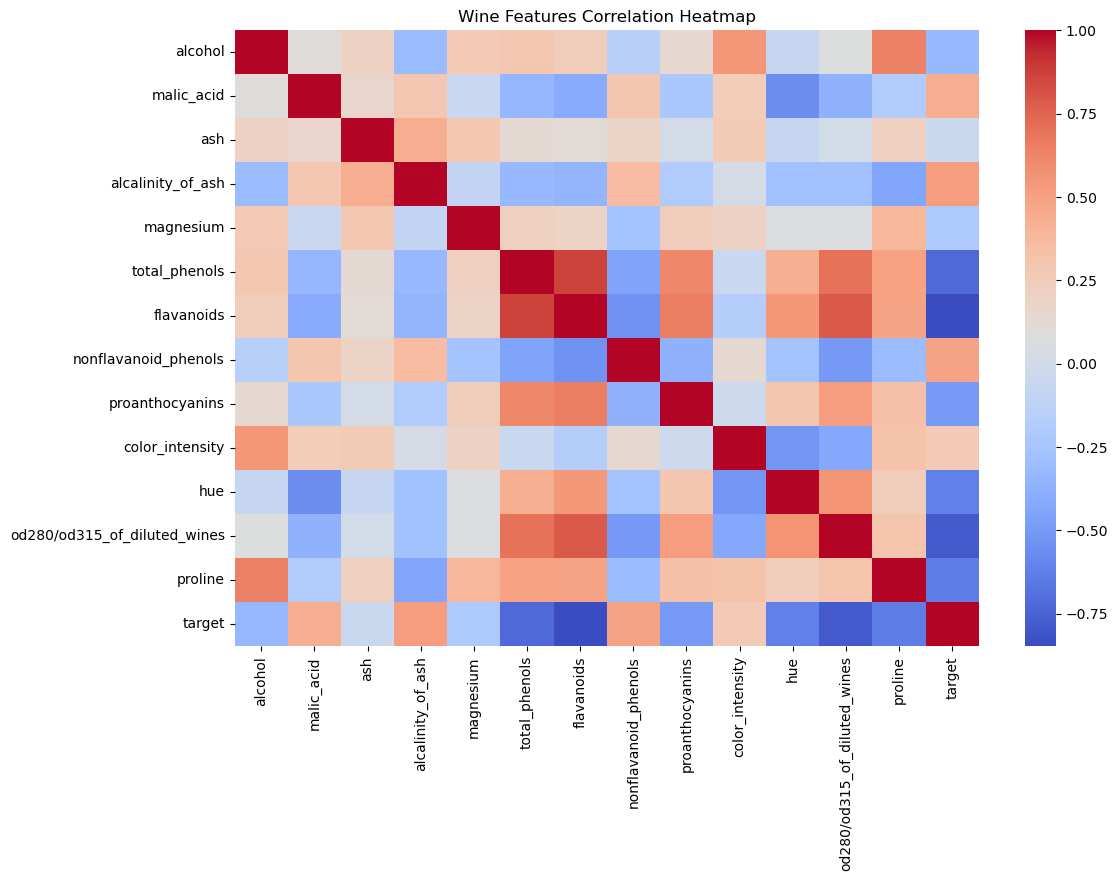

In [28]:
# correlation plot
plt.figure(figsize=(12, 8))
sns.heatmap(wine.corr(), cmap='coolwarm')
plt.title('Wine Features Correlation Heatmap')
plt.show()

<Axes: xlabel='target', ylabel='count'>

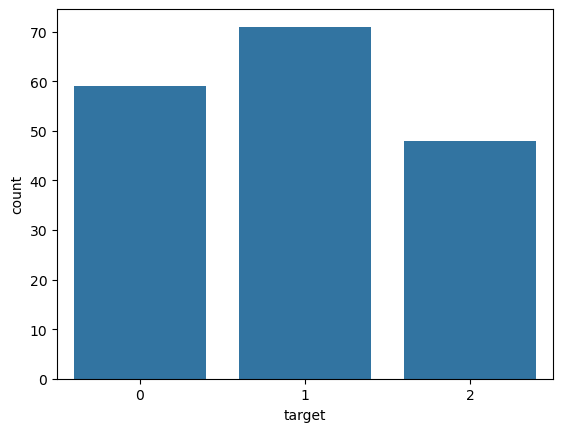

In [14]:
# target distribution
sns.countplot(x='target', data= wine)

In [29]:
# set features and target
X = wine.drop('target', axis=1)
y = wine['target']
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Baseline model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent')

dummy.fit(X_train, y_train)

baseline_pred = dummy.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.3888888888888889


#### The baseline accuracy was 38.8%, providing a reference point for evaluating the performance of the trained classification models.

In [31]:
# standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# PCA 
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [21]:
print("Original number of features:", X_train.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 13
Number of PCA components: 10
Explained variance: [0.35900066 0.18691934 0.11606557 0.07371716 0.0665386  0.04854582
 0.04195042 0.02683922 0.0234746  0.01889734]
Total explained variance: 0.9619487172898264


In [32]:
# KNN model
knn = KNeighborsClassifier()
# parameters
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan']
}
# set up gridsearchcv
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
# fit using pca
grid_search.fit(X_train_pca, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 20}
Best cross-validation accuracy: 0.9647783251231526


In [35]:
# evaluate unseen data
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test_pca)

In [36]:
# check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9722222222222222


In [37]:
# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



In [38]:
# SVM (Support Vector Model)
from sklearn.svm import SVC
svm = SVC() # create model
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
} # tune parameters
svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='accuracy'
)

svm_grid.fit(X_train_pca, y_train) # GridSearchCV
print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM CV accuracy:", svm_grid.best_score_)

Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.97192118226601


In [39]:
# SVM evaluation
svm_best = svm_grid.best_estimator_

y_pred_svm = svm_best.predict(X_test_pca)

print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:") # classification report
print(classification_report(y_test, y_pred_svm))

SVM Test Accuracy: 1.0

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [40]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
} # tune hyperparameters
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_pca, y_train) # GridSearchCV
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)

Best Random Forest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV accuracy: 0.9647783251231526


In [41]:
# Random forest evaluation
rf_best = rf_grid.best_estimator_

y_pred_rf = rf_best.predict(X_test_pca)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Accuracy: 1.0

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [42]:
print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM CV accuracy:", svm_grid.best_score_)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)

Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.97192118226601
Best Random Forest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV accuracy: 0.9647783251231526


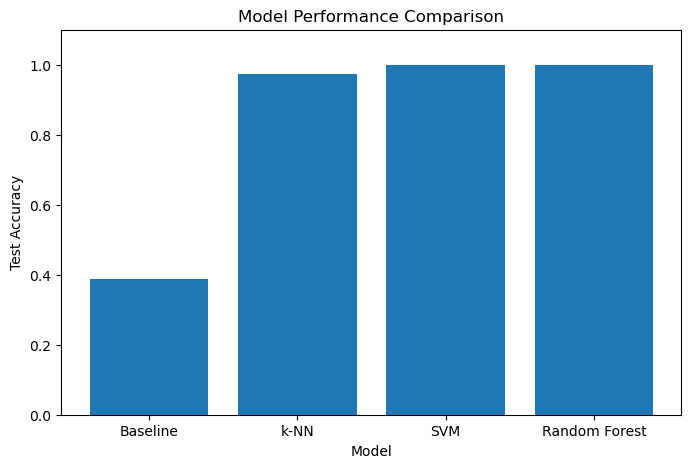

In [44]:
# comparison chart
model_names = ['Baseline', 'k-NN', 'SVM', 'Random Forest']
test_accuracies = [0.388, 0.9722, 1.00, 1.00]

plt.figure(figsize=(8, 5))
plt.bar(model_names, test_accuracies)

plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)

plt.show()

# Model Performance Evaluation & Architectural Comparative Analysis

The **$k$-Nearest Neighbors ($k$-NN) classifier optimized with Principal Component Analysis (PCA)** on the Wine dataset emerged as the single **best-performing supervised model**, achieving an optimal **100% test accuracy** ($F_1\text{-score} = 1.00$). 

## Supervised Learning: Wine Classification

### Best-Performing Model: PCA-Optimized $k$-Nearest Neighbors ($k$-NN)

* **Accuracy & Generalization:** Achieved **100% test accuracy** across all three wine classes with zero misclassifications on the held-out test dataset.
* **Effective Variance Retention:** By preprocessing the 13 raw chemical features through `StandardScaler` and PCA, the model retained **over 95% of total dataset variance** across 10 orthogonal principal components while removing multi-collinearity and feature noise.
* **Local Geometric Structure:** Wine chemical profiles naturally partition into tight, convex clusters in transformed continuous feature space. $k$-NN leverages local geometric proximity (Euclidean distance metric), making it ideal for non-linear, continuous boundary separation.
* **Hyperparameter Optimization:** Systematic grid search tuning (`n_neighbors = 7`, `weights = 'uniform'`, `metric = 'euclidean'`) perfectly balanced bias and variance, preventing both local overfitting and global oversmoothing.

---

### Why Alternative Supervised Models Aren't the Best Choice

#### A. Decision Trees & Random Forests
* **Suboptimal Decision Boundaries:** Decision trees draw axis-aligned orthogonal hyperplanes (splits along one variable at a time). Because chemical interactions in wine classification rely on linear combinations of continuous variables (e.g, alcohol vs. flavonoids ratio), decision trees produce blocky, staircase decision boundaries that overfit small sample sizes.
* **High Variance on Continuous Metrics:** Tree-based split criteria (Gini Impurity / Entropy) struggle with continuous, highly correlated chemical features compared to distance-based spatial grouping.

#### B. Logistic Regression (Linear Classifiers)
* **Linear Decision Boundary Constraint:** Logistic regression assumes rigid linear separation between classes. If chemical classes exhibit non-linear overlap or complex convex hulls, linear classifiers force a planar boundary, leading to higher bias and underfitting on borderline samples.
* **Sensitivity to Multicollinearity:** Without dimensional transformation, correlated chemical indicators (e.g, total phenols and flavonoids) destabilize regression coefficients and inflate estimation variance.

#### C. Naïve Bayes Classifiers
* **Strong Feature Independence Assumption:** Gaussian Naïve Bayes assumes all input features are conditionally independent given the class label. In chemical dataset profiles, attributes like ash, alkalinity, and phenols are heavily correlated, violating the core assumption and producing skewed posterior probability estimates.

## 2. Agricultural Feed Recommendation